데이터 생성

In [1]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv("lsh2024000629.csv", encoding="cp949")
df.head()

Saving lsh2024000629.csv to lsh2024000629 (1).csv


,시도별(1),월별(1),2013,2013.1,2013.2,2014,2014.1,2014.2,2015,2015.1,...,2020.2,2021,2021.1,2021.2,2022,2022.1,2022.2,2023,2023.1,2023.2
0,시도별(1),월별(1),사고건수 (건),사망자수 (명),부상자수 (명),사고건수 (건),사망자수 (명),부상자수 (명),사고건수 (건),사망자수 (명),...,부상자수 (명),사고건수 (건),사망자수 (명),부상자수 (명),사고건수 (건),사망자수 (명),부상자수 (명),사고건수 (건),사망자수 (명),부상자수 (명)
1,서울,전체,39439,378,56761,40792,400,57345,41665,376,...,47513,33913,243,45223,33698,221,45329,33811,180,45414
2,서울,1월,3005,25,4543,2687,30,3880,2967,38,...,3944,2717,17,3690,2874,18,3868,2526,14,3407
3,서울,2월,2562,19,3840,2566,27,3624,2682,26,...,3980,2505,21,3334,2176,16,2919,2279,15,3105
4,서울,3월,3311,40,4708,3335,32,4624,3384,29,...,3385,2789,12,3740,2187,12,2852,2632,18,3442


데이터 정제

In [2]:
df = df.rename(columns={"시도별(1)":"지역", "월별(1)":"월"})
df = df[df["월"] == "전체"]

for col in df.columns:
    df[col] = df[col].astype(str).replace(",", "", regex=True)

numeric_cols = [col for col in df.columns if col not in ["지역","월"]]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

df.head()


,지역,월,2013,2013.1,2013.2,2014,2014.1,2014.2,2015,2015.1,...,2020.2,2021,2021.1,2021.2,2022,2022.1,2022.2,2023,2023.1,2023.2
1,서울,전체,39439,378,56761,40792,400,57345,41665,376,...,47513,33913,243,45223,33698,221,45329,33811,180,45414
14,부산,전체,12606,213,17542,12693,168,18030,12757,178,...,16347,11339,113,15457,10882,113,14829,11003,103,14967
27,대구,전체,13680,165,19713,14519,185,20814,14228,161,...,18974,12133,84,17230,11102,68,15721,10880,86,15388
40,인천,전체,8990,157,13594,8846,149,13420,8727,136,...,11950,7912,104,10730,7695,95,10533,7648,83,10347
53,광주,전체,8036,111,13089,8194,101,13289,7864,97,...,12293,7543,49,11489,7122,58,10722,6972,48,10490


상관관계

In [3]:
years = range(2013, 2023+1)

results = []

for y in years:
    corr_value = df[[f'{y}.1', f'{y}.2']].corr(method='pearson').iloc[0, 1]
    results.append([y, round(corr_value, 4)])

df_corr = pd.DataFrame(results, columns=["연도", "피어슨 상관계수"])
print(df_corr)

      연도  피어슨 상관계수
0   2013    0.7752
1   2014    0.8169
2   2015    0.8166
3   2016    0.7965
4   2017    0.8119
5   2018    0.7790
6   2019    0.7865
7   2020    0.7942
8   2021    0.7878
9   2022    0.8087
10  2023    0.8003


In [ ]:
! sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib-rf


^C
/usr/share/fonts: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/X11: caching, new cache contents: 0 fonts, 4 dirs
/usr/share/fonts/X11/Type1: caching, new cache contents: 8 fonts, 0 dirs
/usr/share/fonts/X11/cyrillic: caching, new cache contents: 0 fonts, 0 dirs
/usr/share/fonts/X11/encodings: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/X11/encodings/large: caching, new cache contents: 0 fonts, 0 dirs
/usr/share/fonts/X11/util: caching, new cache contents: 0 fonts, 0 dirs
/usr/share/fonts/opentype: caching, new cache contents: 0 fonts, 2 dirs
/usr/share/fonts/opentype/ipafont-gothic: caching, new cache contents: 2 fonts, 0 dirs
/usr/share/fonts/opentype/tlwg: caching, new cache contents: 4 fonts, 0 dirs
/usr/share/fonts/truetype: caching, new cache contents: 1 fonts, 7 dirs
/usr/share/fonts/truetype/freefont: caching, new cache contents: 12 fonts, 0 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fo

In [23]:
!wget https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf
!cp NanumGothic-Regular.ttf /usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/


--2025-12-01 02:42:32--  https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/google/fonts/main/ofl/nanumgothic/NanumGothic-Regular.ttf [following]
--2025-12-01 02:42:32--  https://raw.githubusercontent.com/google/fonts/main/ofl/nanumgothic/NanumGothic-Regular.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2054744 (2.0M) [application/octet-stream]
Saving to: ‘NanumGothic-Regular.ttf’

NanumGothic-Regular 100%[===================>]   1.96M  --.-KB/s    in 0.02s   

2025-12-01 02:42:32 (78.6 MB/s) - ‘NanumGothic-Regul

In [8]:
import matplotlib
import shutil

cache_dir = matplotlib.get_cachedir()
shutil.rmtree(cache_dir, ignore_errors=True)
print("캐시 삭제 완료:", cache_dir)

캐시 삭제 완료: /root/.cache/matplotlib


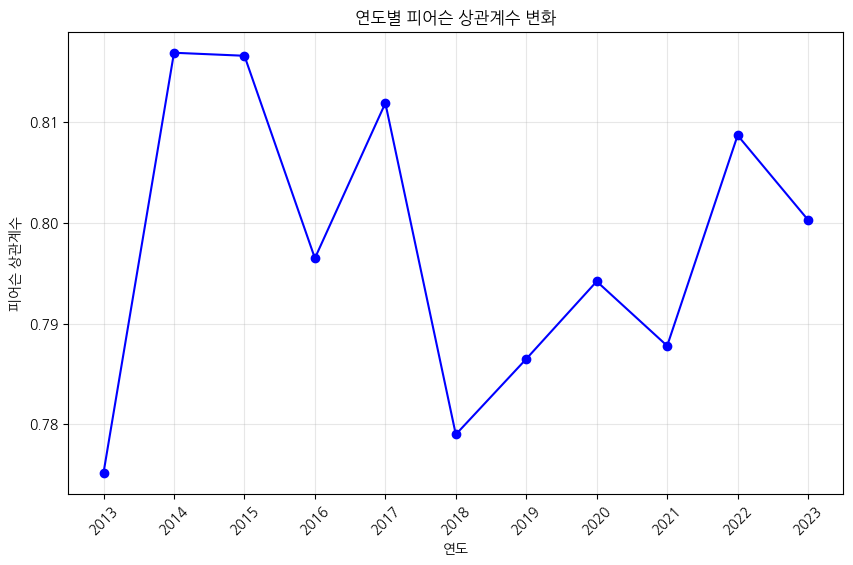

In [4]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'NanumGothic'

plt.figure(figsize=(10, 6))
plt.plot(df_corr['연도'], df_corr['피어슨 상관계수'], marker='o', linestyle='-', color='blue')

plt.title('연도별 피어슨 상관계수 변화')
plt.xlabel('연도')
plt.ylabel('피어슨 상관계수')
plt.grid(alpha=0.3)

plt.xticks(df_corr['연도'], rotation=45)
plt.show()


In [5]:
years = range(2013, 2023+1)

results_s = []

for y in years:
    corr_val = df[[f'{y}.1', f'{y}.2']].corr(method='spearman').iloc[0, 1]
    results_s.append([y, round(corr_val, 4)])

df_spearman = pd.DataFrame(results_s, columns=["연도", "스피어만 상관계수"])
print(df_spearman)

      연도  스피어만 상관계수
0   2013     0.8015
1   2014     0.7892
2   2015     0.8277
3   2016     0.8137
4   2017     0.8284
5   2018     0.7132
6   2019     0.6961
7   2020     0.7181
8   2021     0.7108
9   2022     0.7574
10  2023     0.7892


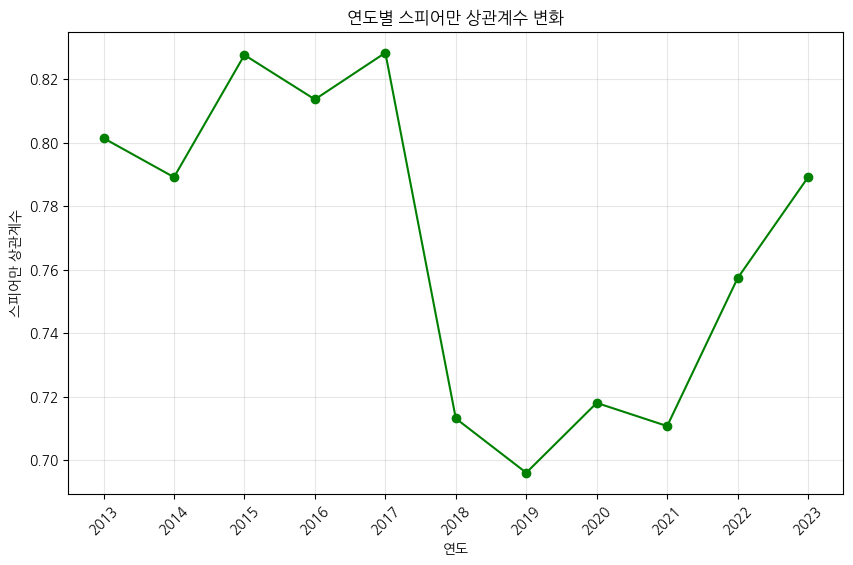

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(df_spearman['연도'], df_spearman['스피어만 상관계수'],
         marker='o', linestyle='-', color='green')

plt.title('연도별 스피어만 상관계수 변화')
plt.xlabel('연도')
plt.ylabel('스피어만 상관계수')
plt.grid(alpha=0.3)
plt.xticks(df_spearman['연도'], rotation=45)

plt.show()

In [7]:
years = range(2013, 2023+1)

results_k = []

for y in years:
    corr_val = df[[f'{y}.1', f'{y}.2']].corr(method='kendall').iloc[0, 1]
    results_k.append([y, round(corr_val, 4)])

df_kendall = pd.DataFrame(results_k, columns=["연도", "켄달 상관계수"])
print(df_kendall)


      연도  켄달 상관계수
0   2013   0.6471
1   2014   0.6618
2   2015   0.6864
3   2016   0.6618
4   2017   0.6765
5   2018   0.5294
6   2019   0.5000
7   2020   0.5882
8   2021   0.5441
9   2022   0.6029
10  2023   0.6324


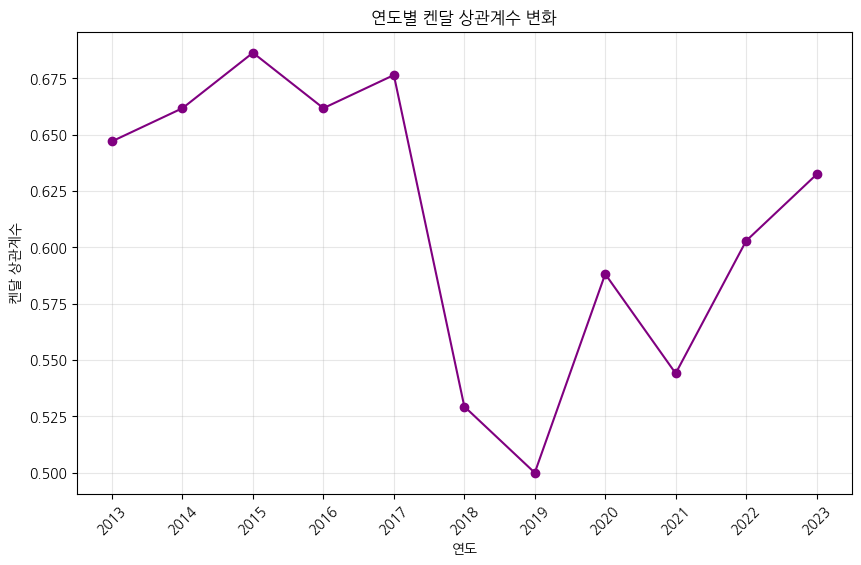

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(df_kendall['연도'], df_kendall['켄달 상관계수'],
         marker='o', linestyle='-', color='purple')

plt.title('연도별 켄달 상관계수 변화')
plt.xlabel('연도')
plt.ylabel('켄달 상관계수')
plt.grid(alpha=0.3)
plt.xticks(df_kendall['연도'], rotation=45)

plt.show()

선형회귀

In [9]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

키 = df["2023"].tolist()             # 사고건수
몸무게 = df["2023.2"].tolist()       # 부상자수

df_lin = pd.DataFrame({
    '사고건수': 키,
    '부상자수': 몸무게
})

X = df_lin[['사고건수']]
y = df_lin['부상자수']

model = LinearRegression()
model.fit(X, y)

기울기 = model.coef_[0]
절편 = model.intercept_

print(f"회귀식: 부상자수 = {기울기:.2f} × 사고건수 + {절편:.2f}")


회귀식: 부상자수 = 1.44 × 사고건수 + -60.79


In [10]:
예측사고 = [[3000]]
예측부상 = model.predict(예측사고)
print(f"사고건수가 3000일 때 예상 부상자수: {예측부상[0]:.1f}명")

plt.rcParams['font.family'] = 'NanumGothic'



사고건수가 3000일 때 예상 부상자수: 4248.4명


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


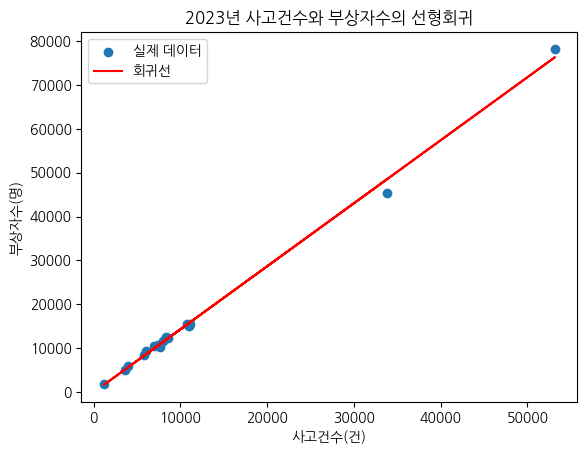

In [11]:
plt.scatter(키, 몸무게, label='실제 데이터')
plt.plot(키, model.predict(pd.DataFrame(키)), 'r-', label='회귀선')

plt.xlabel('사고건수(건)')
plt.ylabel('부상자수(명)')
plt.legend()
plt.title("2023년 사고건수와 부상자수의 선형회귀")
plt.show()

주성분 분석

In [12]:
import numpy as np
from sklearn.decomposition import PCA

사고건수 = df["2023"].tolist()
사망자수 = df["2023.1"].tolist()
부상자수 = df["2023.2"].tolist()

원본_데이터 = np.array([사고건수, 사망자수, 부상자수]).T

print("\n=== 원본 데이터 ===")
print("사고건수  사망자수  부상자수")
print(원본_데이터)



=== 원본 데이터 ===
사고건수  사망자수  부상자수
[[33811   180 45414]
 [11003   103 14967]
 [10880    86 15388]
 [ 7648    83 10347]
 [ 6972    48 10490]
 [ 7398    61 10629]
 [ 3664    40  5114]
 [ 1166    13  1724]
 [53164   502 78234]
 [ 6079   140  9354]
 [ 7939   154 11736]
 [ 8606   198 12392]
 [ 5830   171  8538]
 [ 8287   227 12594]
 [10777   263 15596]
 [11122   237 15398]
 [ 3950    45  5884]]


In [13]:
pca = PCA(n_components=2)
pca.fit(원본_데이터)
변환된_데이터 = pca.transform(원본_데이터)

print("\n=== 변환된 데이터 ===")
print("제1주성분   제2주성분")
print(np.round(변환된_데이터, 2))



=== 변환된 데이터 ===
제1주성분   제2주성분
[[ 3.622219e+04  1.804830e+03]
 [-1.795940e+03  4.437800e+02]
 [-1.520450e+03  1.043100e+02]
 [-7.504410e+03  3.245600e+02]
 [-7.772820e+03 -3.089200e+02]
 [-7.415550e+03 -3.959000e+01]
 [-1.407528e+04  4.004000e+01]
 [-1.828467e+04 -7.637000e+01]
 [ 7.421881e+04 -1.032650e+03]
 [-9.214880e+03 -3.999600e+02]
 [-6.197370e+03 -2.319600e+02]
 [-5.277880e+03 -6.128000e+01]
 [-1.002695e+04 -1.414600e+02]
 [-5.293890e+03 -4.395800e+02]
 [-1.407660e+03 -1.093900e+02]
 [-1.373520e+03  2.877700e+02]
 [-1.327972e+04 -1.641400e+02]]


In [14]:
설명력 = pca.explained_variance_ratio_

print("\n=== PCA 설명력 ===")
print(f"제1주성분의 설명력: {설명력[0]:.2%}")
print(f"제2주성분의 설명력: {설명력[1]:.2%}")



=== PCA 설명력 ===
제1주성분의 설명력: 99.93%
제2주성분의 설명력: 0.07%


In [ ]:
시계열

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

dates = pd.date_range(start="2013-01-01", periods=11, freq='Y')
print(dates)

values = [
    df["2013"].iloc[0], df["2014"].iloc[0], df["2015"].iloc[0],
    df["2016"].iloc[0], df["2017"].iloc[0], df["2018"].iloc[0],
    df["2019"].iloc[0], df["2020"].iloc[0], df["2021"].iloc[0],
    df["2022"].iloc[0], df["2023"].iloc[0]
]

data = pd.DataFrame({"Date": dates, "Accidents": values})
data.set_index("Date", inplace=True)


model = ARIMA(data["Accidents"], order=(1,1,1))
fitted_model = model.fit()



/tmp/ipython-input-2506789622.py:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(start="2013-01-01", periods=11, freq='Y')
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)


DatetimeIndex(['2013-12-31', '2014-12-31', '2015-12-31', '2016-12-31',
               '2017-12-31', '2018-12-31', '2019-12-31', '2020-12-31',
               '2021-12-31', '2022-12-31', '2023-12-31'],
              dtype='datetime64[ns]', freq='YE-DEC')


In [16]:
forecast = fitted_model.forecast(steps=3)

print("\n=== 예측 결과 (2024~2026 사고건수) ===")
print(forecast)


=== 예측 결과 (2024~2026 사고건수) ===
2024-12-31    33544.893795
2025-12-31    33810.898350
2026-12-31    33544.995407
Freq: YE-DEC, Name: predicted_mean, dtype: float64


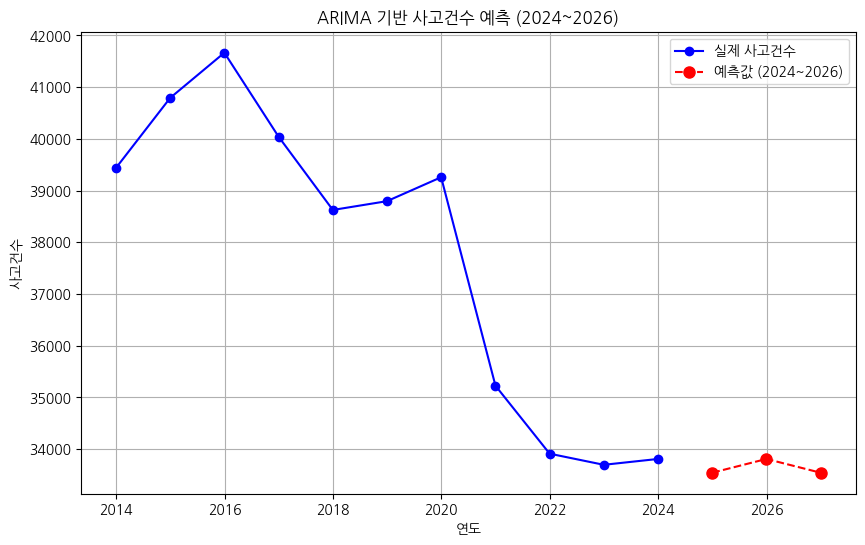

In [17]:
future_years = [
    data.index[-1] + pd.DateOffset(years=i)
    for i in range(1, 4)
]


plt.figure(figsize=(10,6))


plt.plot(data.index, data["Accidents"], 'o-', label="실제 사고건수", color='blue')


plt.plot(future_years, forecast.values, 'ro--', label="예측값 (2024~2026)", markersize=8)

plt.title("ARIMA 기반 사고건수 예측 (2024~2026)")
plt.xlabel("연도")
plt.ylabel("사고건수")
plt.grid(True)
plt.legend()
plt.show()